<a href="https://colab.research.google.com/github/IraSamsonova/nn/blob/main/autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [22]:
BATCH_SIZE = 128  # Размер батча для обучения
LEARNING_RATE = 0.0001  # Скорость обучения
EPOCHS = 100 # Количество эпох
LATENT_DIM = 32  # Размерность латентного пространства

transform = transforms.Compose([
    transforms.ToTensor(),  # Конвертация в тензор [0, 1]
    transforms.Normalize((0.5,), (0.5,)),  # нормализация [0,1] в [-1,1]
    transforms.Lambda(lambda x: x.view(-1))  # Развертка в 1D вектор
])

ЗАГРУЗКА ДАТАСЕТА MNIST - рукописные цифры от 0 до 9 (60000 обучающих и 10000 тестовых изображений 28x28)

In [23]:
train_dataset = datasets.MNIST(root='data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='data', train=False, transform=transform, download=True)

In [24]:
# Data Loader
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [25]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim=784, latent_dim=32):
        super().__init__()

        # encoder - сжатие
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),  # Полносвязный слой 784 в 512
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        #decoder - восстановление
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim),
            nn.Tanh() # Активация для значений [-1, 1]
        )

    def forward(self, x):
         # Вход → Энкодер → Декодер
        latent_x = self.encoder(x)
        decoded_x = self.decoder(latent_x)
        return decoded_x

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

In [26]:
model = AutoEncoder(input_dim=784, latent_dim=LATENT_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)  # Оптимизатор Adam
criterion = nn.MSELoss()  # Функция потерь
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for data, _ in train_loader:
        data = data.to(device)  # Перемещение батча на устройство

        # прямой
        reconstructed = model(data)  # Проход через автоэнкодер
        loss = criterion(reconstructed, data)  # Вычисление потерь

        # обратный
        optimizer.zero_grad()  # Обнуление градиентов
        loss.backward() # Вычисление градиентов
        optimizer.step() # Обновление весов

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f'Эпоха [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}')

Эпоха [1/100], Loss: 0.2928
Эпоха [2/100], Loss: 0.1674
Эпоха [3/100], Loss: 0.1207
Эпоха [4/100], Loss: 0.1038
Эпоха [5/100], Loss: 0.0925
Эпоха [6/100], Loss: 0.0843
Эпоха [7/100], Loss: 0.0782
Эпоха [8/100], Loss: 0.0729
Эпоха [9/100], Loss: 0.0681
Эпоха [10/100], Loss: 0.0642
Эпоха [11/100], Loss: 0.0610
Эпоха [12/100], Loss: 0.0581
Эпоха [13/100], Loss: 0.0557
Эпоха [14/100], Loss: 0.0536
Эпоха [15/100], Loss: 0.0518
Эпоха [16/100], Loss: 0.0501
Эпоха [17/100], Loss: 0.0486
Эпоха [18/100], Loss: 0.0472
Эпоха [19/100], Loss: 0.0459
Эпоха [20/100], Loss: 0.0448
Эпоха [21/100], Loss: 0.0436
Эпоха [22/100], Loss: 0.0426
Эпоха [23/100], Loss: 0.0416
Эпоха [24/100], Loss: 0.0406
Эпоха [25/100], Loss: 0.0397
Эпоха [26/100], Loss: 0.0389
Эпоха [27/100], Loss: 0.0381
Эпоха [28/100], Loss: 0.0373
Эпоха [29/100], Loss: 0.0366
Эпоха [30/100], Loss: 0.0359
Эпоха [31/100], Loss: 0.0353
Эпоха [32/100], Loss: 0.0347
Эпоха [33/100], Loss: 0.0342
Эпоха [34/100], Loss: 0.0337
Эпоха [35/100], Loss: 0

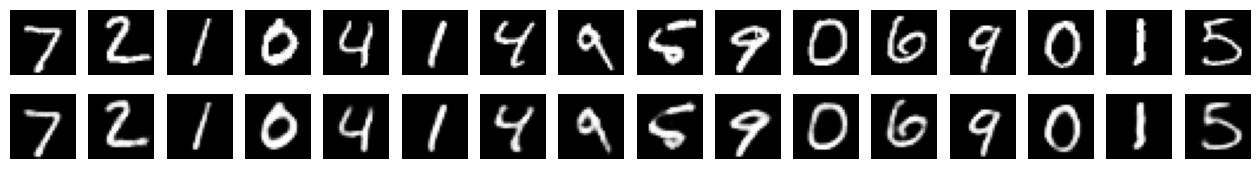

In [27]:
# Визуализация восстановления цифр
model.eval()
with torch.no_grad(): # Отключение вычисления градиентов
    data, _ = next(iter(test_loader))
    data = data[:16].to(device) #16 изображений MNIST
    reconstructed = model(data)

    # денормализация для отображения [0,1]
    data = (data.view(-1,28,28).cpu() + 1)/2
    reconstructed = (reconstructed.view(-1,28,28).cpu() + 1)/2

    fig, axes = plt.subplots(2, 16, figsize=(16, 2))
    for i in range(16):
        axes[0, i].imshow(data[i], cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(reconstructed[i], cmap='gray')
        axes[1, i].axis('off')
    plt.show()

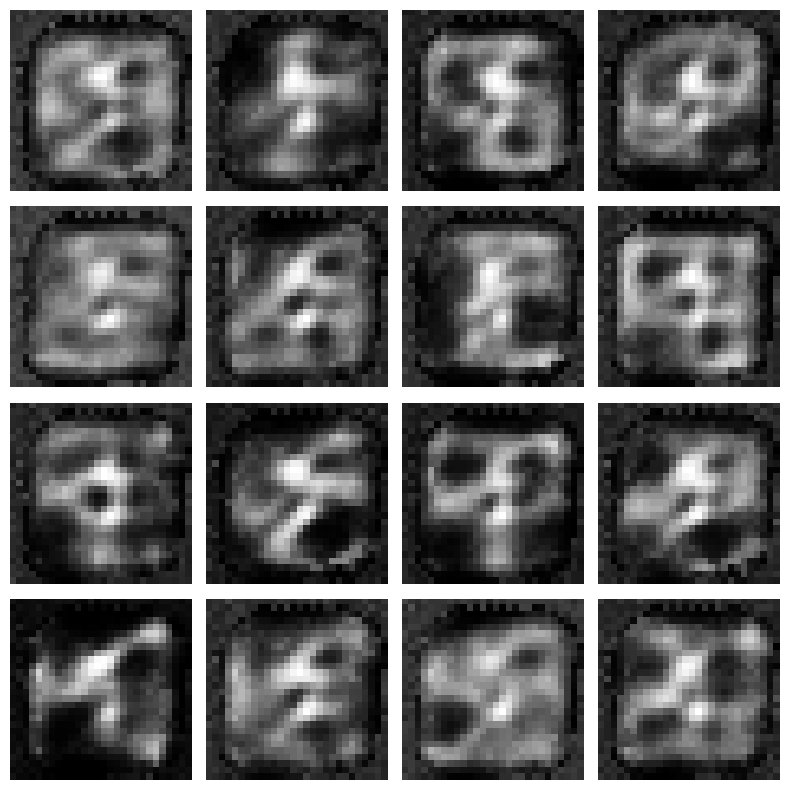

In [32]:
model.eval()  # Перевод модели в режим оценки

num_images = 16
with torch.no_grad():
    # создаём случайные латентные векторы
    random_vectors = torch.randn(num_images, LATENT_DIM).to(device)

    # декодируем их
    generated = model.decode(random_vectors)

    # денормализация для Tanh [-1,1] в [0,1]
    generated = (generated.view(-1, 28, 28).cpu() + 1) / 2

    # отображение
    cols = 4
    rows = (num_images + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
    for i in range(num_images):
        ax = axes.flat[i]
        ax.imshow(generated[i], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.show()
